# OTT Content Trend Analysis (Netflix catalog)

Dataset: Netflix Movies and TV Shows (Kaggle, Shivam Bansal). 8,807 titles, data till Sept 2021.

**Sawal jo mujhe solve karna hai:** Netflix ke catalog mein kya trend chal raha hai - genre, country, release year aur movie length ke hisaab se? Isse ek content team ko kya decision milega?

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

sns.set_style("whitegrid")
df = pd.read_csv("netflix_titles.csv")
print(df.shape)
df.head()

(8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.info()
print(df.isnull().sum())
print(df['type'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0


**Pehli nazar mein:** director mein sabse zyada missing hai (2634), country mein 831 aur cast mein 825. date_added mein sirf 10 missing hain. Director aur cast ka mujhe trend analysis mein kaam nahi hai, to unko chhod diya.

In [5]:
# --- Cleaning ---
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

# date_added mein extra space tha, strip karna pada
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year

# duration: movie ke liye "90 min", show ke liye "2 Seasons" - number alag nikala
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)

# ek title ke kai country/genre hote hain, simple rakhne ke liye pehla wala le raha hoon
df['main_country'] = df['country'].str.split(',').str[0].str.strip()
df['main_genre'] = df['listed_in'].str.split(',').str[0].str.strip()

print("duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
df[['title','type','main_country','main_genre','year_added','duration_num']].head()

duplicates: 0


,title,type,main_country,main_genre,year_added,duration_num
0,Dick Johnson Is Dead,Movie,United States,Documentaries,2021.0,90.0
1,Blood & Water,TV Show,South Africa,International TV Shows,2021.0,2.0
2,Ganglands,TV Show,Unknown,Crime TV Shows,2021.0,1.0
3,Jailbirds New Orleans,TV Show,Unknown,Docuseries,2021.0,1.0
4,Kota Factory,TV Show,India,International TV Shows,2021.0,2.0


**Cleaning notes:** duplicates 0 mile. Pehla country/genre lene ka matlab hai multi-country co-productions ek hi country mein count hongi - ye is analysis ki limitation hai, report mein bhi likhunga.

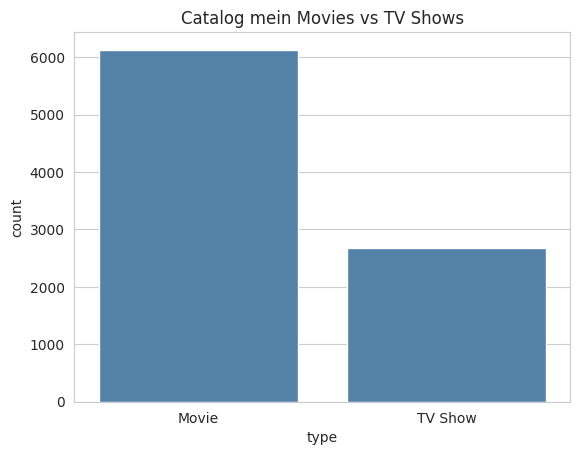

type
Movie      0.696
TV Show    0.304
Name: proportion, dtype: float64


In [6]:
# Chart 1: Movies vs TV Shows
sns.countplot(data=df, x='type', color='steelblue')
plt.title("Catalog mein Movies vs TV Shows")
plt.show()
print(df['type'].value_counts(normalize=True).round(3))

**Chart 1:** Catalog ka lagbhag 70% Movies hai (6131) aur 30% TV Shows (2676).

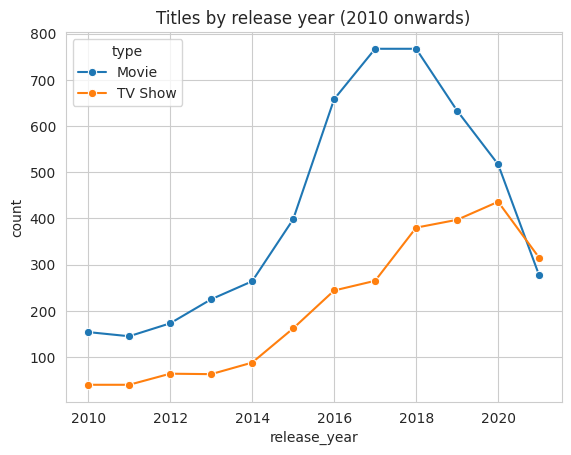

In [7]:
# Chart 2: Release year ke hisaab se count (2010 ke baad)
yearly = (df[df['release_year'] >= 2010]
          .groupby(['release_year', 'type']).size().reset_index(name='count'))
sns.lineplot(data=yearly, x='release_year', y='count', hue='type', marker='o')
plt.title("Titles by release year (2010 onwards)")
plt.show()

**Chart 2:** Movies 2017-18 ke aas-paas peak par gayi aur uske baad girti gayi. TV Shows 2020 tak badhte rahe. Note: 2021 ka data adhura hai (dataset Sept 2021 tak ka hai), isliye wo girawat poori sach nahi.

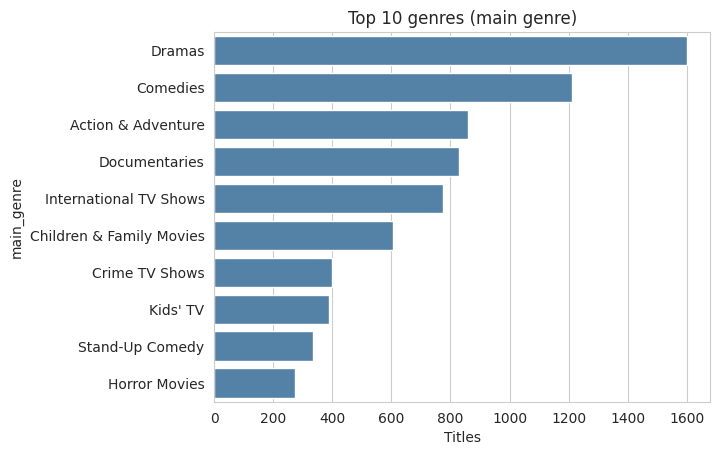

In [8]:
# Chart 3: Top 10 genres
top_genres = df['main_genre'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, color='steelblue')
plt.title("Top 10 genres (main genre)")
plt.xlabel("Titles")
plt.show()

**Chart 3:** Dramas (1600) aur Comedies (1210) clear top par hain. Teesre number par Action & Adventure aur Documentaries lagbhag barabar hain.

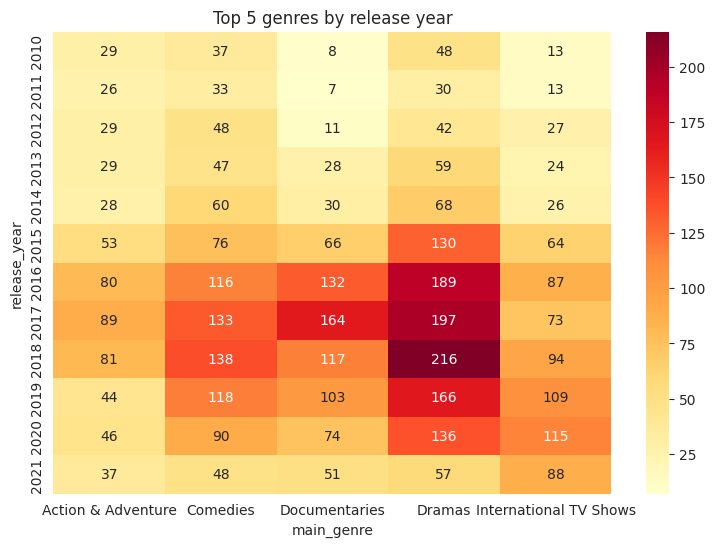

In [9]:
# Chart 4: genre mix heatmap
top5 = df['main_genre'].value_counts().head(5).index
mix = df[df['main_genre'].isin(top5) & (df['release_year'] >= 2010)]
pivot = pd.crosstab(mix['release_year'], mix['main_genre'])
plt.figure(figsize=(9, 6))
sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt='d')
plt.title("Top 5 genres by release year")
plt.show()

**Chart 4:** Dramas aur Comedies dono 2018 mein peak par the (216 aur 138) aur uske baad girte gaye. Lekin International TV Shows 2018 ke 94 se badhke 2020 mein 115 ho gaye - jab baaki genres neeche ja rahe the tab ye upar gaya. 2021 adhura saal hai.

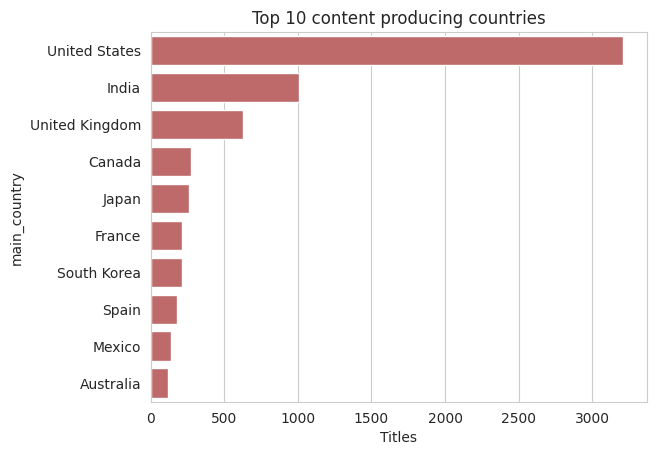

In [10]:
# Chart 5: Top 10 countries
top_c = df[df['main_country'] != 'Unknown']['main_country'].value_counts().head(10)
sns.barplot(x=top_c.values, y=top_c.index, color='indianred')
plt.title("Top 10 content producing countries")
plt.xlabel("Titles")
plt.show()

**Chart 5:** US (3211) pehle number par hai aur India (1008) doosre par, UK teesre (628). India ka US ke baad hona mere liye surprise tha.

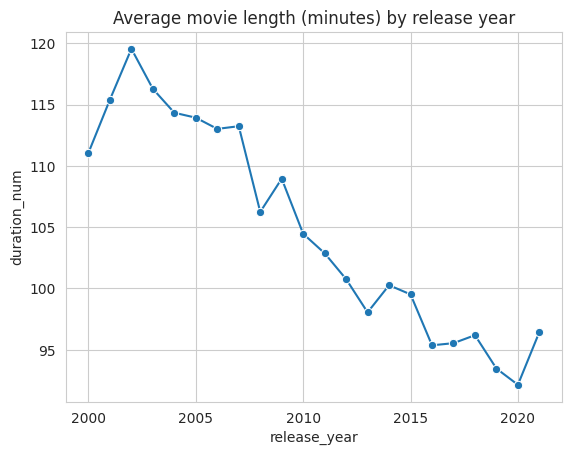

In [11]:
# Chart 6: Movie duration trend
movies = df[df['type'] == 'Movie']
avg_dur = movies.groupby('release_year')['duration_num'].mean().reset_index()
avg_dur = avg_dur[avg_dur['release_year'] >= 2000]
sns.lineplot(data=avg_dur, x='release_year', y='duration_num', marker='o')
plt.title("Average movie length (minutes) by release year")
plt.show()

**Chart 6:** 2000-2002 mein average movie lagbhag 115-119 min ki thi, 2020 tak ye 92 min ke paas aa gayi. Yani movies chhoti ho rahi hain.

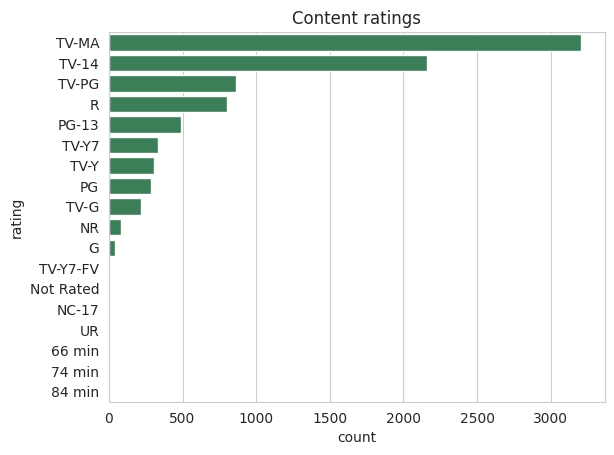

In [12]:
# Chart 7 (bonus): ratings
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, color='seagreen')
plt.title("Content ratings")
plt.show()

**Chart 7:** TV-MA (3207) aur TV-14 (2160) mil ke catalog ka lagbhag 61% hain - matlab zyadatar content adults/teens ke liye hai, kids ka share chhota hai.

## SQL part
Same data ko SQLite mein daal ke core numbers SQL se nikaal raha hoon.

In [13]:
conn = sqlite3.connect("netflix.db")
df[['type','title','main_country','release_year','year_added','rating','main_genre','duration_num']] \
    .to_sql("titles", conn, index=False, if_exists="replace")

8807

In [14]:
q1 = """
SELECT main_genre, COUNT(*) AS total
FROM titles
GROUP BY main_genre
ORDER BY total DESC
LIMIT 10;
"""
pd.read_sql(q1, conn)

,main_genre,total
0,Dramas,1600
1,Comedies,1210
2,Action & Adventure,859
3,Documentaries,829
4,International TV Shows,774
5,Children & Family Movies,605
6,Crime TV Shows,399
7,Kids' TV,388
8,Stand-Up Comedy,334
9,Horror Movies,275


In [15]:
q2 = """
SELECT year_added, type, COUNT(*) AS added
FROM titles
WHERE year_added IS NOT NULL
GROUP BY year_added, type
ORDER BY year_added;
"""
pd.read_sql(q2, conn)

,year_added,type,added
0,2008.0,Movie,1
1,2008.0,TV Show,1
2,2009.0,Movie,2
3,2010.0,Movie,1
4,2011.0,Movie,13
5,2012.0,Movie,3
6,2013.0,Movie,6
7,2013.0,TV Show,5
8,2014.0,Movie,19
9,2014.0,TV Show,5


In [16]:
q3 = """
SELECT main_country, COUNT(*) AS total
FROM titles
WHERE main_country != 'Unknown'
GROUP BY main_country
HAVING COUNT(*) > 50
ORDER BY total DESC;
"""
pd.read_sql(q3, conn)

,main_country,total
0,United States,3211
1,India,1008
2,United Kingdom,628
3,Canada,271
4,Japan,259
5,France,212
6,South Korea,211
7,Spain,181
8,Mexico,134
9,Australia,117


In [17]:
q4 = """
SELECT release_year, ROUND(AVG(duration_num), 1) AS avg_minutes
FROM titles
WHERE type = 'Movie' AND release_year >= 2000
GROUP BY release_year
ORDER BY release_year;
"""
pd.read_sql(q4, conn)

,release_year,avg_minutes
0,2000,111.1
1,2001,115.4
2,2002,119.5
3,2003,116.3
4,2004,114.3
5,2005,113.9
6,2006,113.0
7,2007,113.2
8,2008,106.2
9,2009,108.9


In [18]:
# Excel pivot ke liye clean file
df.to_csv("netflix_clean.csv", index=False)